# Big Data Programming Project
## Detecting unusual municipality-year energy profiles in Sweden

## 1. Project overview

`Jakob Wennergrund & Robin Dogan`

This project investigates whether anomaly detection can identify municipality-year observations with unusual energy profiles in Swedish municipal energy data.

The analysis combines three parts of the municipal energy system:
- final energy use,
- electricity production,
- district heating production.

The goal is not to predict a labeled target. Instead, the goal is to detect observations that differ from the general multivariate pattern in the data.

This project follows a clear workflow:
1. define the problem and question,
2. describe the data sources,
3. prepare and integrate the data,
4. build the feature matrix,
5. train anomaly detection models,
6. compare and interpret the results,
7. discuss limitations and practical use.

## 2. Problem and investigation question

Municipal energy systems differ across Sweden. Some differences are expected, while others may reflect unusual combinations of consumption, production, or fuel structure.

The problem addressed in this project is how to identify municipality-year observations that look unusual when several energy dimensions are considered together.

### Investigation question
Can anomaly detection identify municipality-year observations with unusual energy profiles in Swedish municipal energy data?

### Final project objective
The objective is to build an unsupervised workflow that combines final energy use, electricity production, and district heating data, and then detect observations that deviate from the general pattern.

## 3. Data sources

This project uses official Swedish municipal energy data from Statistics Sweden (SCB).

Three data sources are used in the project. Each source is provided in two files split by time period.

1. **Final energy use**  
   This dataset describes how much energy is used in different consumption categories.

2. **Electricity production and fuel use**  
   This dataset describes electricity production by production type and fuel type.

3. **District heating production and fuel use**  
   This dataset describes district heating production by production type and fuel type.

The datasets cover Swedish municipalities over multiple years and together describe important parts of the local energy system.

### Why these datasets were selected

These datasets were selected because the project aims to detect unusual municipality-year energy profiles.

A municipality-year profile should reflect more than one part of the energy system. Final energy use shows demand, while electricity production and district heating production show important supply-side characteristics.

By combining these datasets, the analysis can capture broader energy patterns than any single dataset alone.

### Data format and structure

The original data is stored as CSV files.

The source tables are not yet in the format needed for anomaly detection. They contain categorical dimensions such as municipality, year, fuel type, production type, and consumption category.

To support the analysis, the data must be transformed into a municipality-year feature matrix where:
- each row represents one municipality in one year,
- each column represents one feature,
- each cell contains a numeric value used for modeling.

### Files used in the project

The following files are used:

- final energy use, 2005–2008
- final energy use, 2009–2023
- electricity production and fuel use, 2005–2008
- electricity production and fuel use, 2009–2023
- district heating production and fuel use, 2005–2008
- district heating production and fuel use, 2009–2023

The files are split by time period, so each pair must first be combined before the full datasets can be prepared and integrated.

## 4. Data preparation

The source data is not yet in a format that can be used for anomaly detection.

This section prepares the data in a structured sequence:
1. combine files from different time periods,
2. inspect the raw tables,
3. reshape the data,
4. integrate the three sources,
5. build the final municipality-year table.

### 4.1 Combine files within each data source

Each data source is split into two files by time period.

The files are first read and combined so that each source becomes one complete table.

In [27]:
from pathlib import Path
import pandas as pd
import numpy as np

In [28]:
data_dir = Path.cwd() / "data"

In [29]:
files = {
    "use_0508": data_dir / "Slutanvändning (MWh), efter län och kommun, förbrukarkategori samt bränsletyp. År 2005 - 2008.csv",
    "use_0923": data_dir / "Slutanvändning (MWh), efter län och kommun, förbrukarkategori samt bränsletyp. År 2009 - 2023.csv",
    "el_0508": data_dir / "Elproduktion och bränsleanvändning (MWh), efter län och kommun, produktionssätt samt bränsletyp. År 2005 - 2008.csv",
    "el_0923": data_dir / "Elproduktion och bränsleanvändning (MWh), efter län och kommun, produktionssätt samt bränsletyp. År 2009 - 2023.csv",
    "heat_0508": data_dir / "Fjärrvärmeproduktion och bränsleanvändning (MWh), efter län och kommun, produktionssätt samt bränsletyp. År 2005 - 2008.csv",
    "heat_0923": data_dir / "Fjärrvärmeproduktion och bränsleanvändning (MWh), efter län och kommun, produktionssätt samt bränsletyp. År 2009 - 2023.csv",
}

In [30]:
use_a = pd.read_csv(files["use_0508"], encoding="latin1", sep=",")
use_b = pd.read_csv(files["use_0923"], encoding="latin1", sep=",")

el_a = pd.read_csv(files["el_0508"], encoding="latin1", sep=",")
el_b = pd.read_csv(files["el_0923"], encoding="latin1", sep=",")

heat_a = pd.read_csv(files["heat_0508"], encoding="latin1", sep=",")
heat_b = pd.read_csv(files["heat_0923"], encoding="latin1", sep=",")

In [31]:
use_raw = pd.concat([use_a, use_b], ignore_index=True)
el_raw = pd.concat([el_a, el_b], ignore_index=True)
heat_raw = pd.concat([heat_a, heat_b], ignore_index=True)

In [32]:
print("Final energy use:", use_raw.shape)
print("Electricity production:", el_raw.shape)
print("District heating:", heat_raw.shape)

Final energy use: (491760, 5)
Electricity production: (269712, 5)
District heating: (340956, 5)


### 4.2 Inspect the raw structure

The next step is to inspect the combined source tables.

This is done to identify:
- the key columns,
- the value columns,
- and the overall structure of the data.

In [34]:
# Preview final energy use table
use_raw.head()

,region,förbrukarkategori,bränsletyp,år,Slutanvändning (MWh)
0,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2005,4195950
1,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2006,4158066
2,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2007,3689400
3,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2008,4003198
4,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",fast (icke förnybara),2005,0


In [35]:
# Preview electricity production table
el_raw.head()

,region,produktionssätt,bränsletyp,år,Elproduktion och bränsleanvändning (MWh)
0,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2005,12064884
1,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2006,12760970
2,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2007,13531303
3,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2008,13831977
4,00 Riket,kraftvärmeverk + industriellt mottryck,flytande (icke förnybara),2005,..


In [36]:
# Preview district heating table
heat_raw.head()

,region,produktionssätt,bränsletyp,år,Fjärrvärmeproduktion och bränsleanvändning (MWh)
0,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2005,28878151
1,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2006,31540649
2,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2007,30934340
3,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2008,29740485
4,00 Riket,kraftvärmeverk,flytande (icke förnybara),2005,1532682


In [51]:
# Show column names
print("Final energy use columns:")
print(use_raw.columns.tolist())

print("\nElectricity production columns:")
print(el_raw.columns.tolist())

print("\nDistrict heating columns:")
print(heat_raw.columns.tolist())

Final energy use columns:
['region', 'förbrukarkategori', 'bränsletyp', 'år', 'Slutanvändning (MWh)']

Electricity production columns:
['region', 'produktionssätt', 'bränsletyp', 'år', 'Elproduktion och bränsleanvändning (MWh)']

District heating columns:
['region', 'produktionssätt', 'bränsletyp', 'år', 'Fjärrvärmeproduktion och bränsleanvändning (MWh)']


In [52]:
# Show data types
print("Final energy use dtypes:")
print(use_raw.dtypes)

print("\nElectricity production dtypes:")
print(el_raw.dtypes)

print("\nDistrict heating dtypes:")
print(heat_raw.dtypes)

Final energy use dtypes:
region                  object
förbrukarkategori       object
bränsletyp              object
år                       int64
Slutanvändning (MWh)    object
dtype: object

Electricity production dtypes:
region                                      object
produktionssätt                             object
bränsletyp                                  object
år                                           int64
Elproduktion och bränsleanvändning (MWh)    object
dtype: object

District heating dtypes:
region                                              object
produktionssätt                                     object
bränsletyp                                          object
år                                                   int64
Fjärrvärmeproduktion och bränsleanvändning (MWh)    object
dtype: object


The inspection shows that the tables already follow a long-format structure.

Each row represents one region, one year, one category combination, and one value. No additional reshaping is needed at this stage.

### 4.3 Clean and standardize the tables

The three source tables must be standardized before they can be integrated.

This step:
- renames key columns,
- converts missing markers to null values,
- converts the value columns to numeric format,
- and creates a consistent structure across the three sources.

In [37]:
# Copy tables before cleaning
use = use_raw.copy()
el = el_raw.copy()
heat = heat_raw.copy()

In [38]:
# Rename columns to a consistent format
use = use.rename(columns={
    "år": "year",
    "Slutanvändning (MWh)": "value"
})

el = el.rename(columns={
    "år": "year",
    "Elproduktion och bränsleanvändning (MWh)": "value"
})

heat = heat.rename(columns={
    "år": "year",
    "Fjärrvärmeproduktion och bränsleanvändning (MWh)": "value"
})

In [39]:
# Replace SCB missing markers with NaN
use["value"] = use["value"].replace("..", np.nan)
el["value"] = el["value"].replace("..", np.nan)
heat["value"] = heat["value"].replace("..", np.nan)

In [40]:
# Convert year and value columns to numeric format
use["year"] = pd.to_numeric(use["year"], errors="coerce")
use["value"] = pd.to_numeric(use["value"], errors="coerce")

el["year"] = pd.to_numeric(el["year"], errors="coerce")
el["value"] = pd.to_numeric(el["value"], errors="coerce")

heat["year"] = pd.to_numeric(heat["year"], errors="coerce")
heat["value"] = pd.to_numeric(heat["value"], errors="coerce")

In [41]:
# Check the standardized structure
print("Final energy use:")
print(use.dtypes)

print("\nElectricity production:")
print(el.dtypes)

print("\nDistrict heating:")
print(heat.dtypes)

Final energy use:
region                object
förbrukarkategori     object
bränsletyp            object
year                   int64
value                float64
dtype: object

Electricity production:
region              object
produktionssätt     object
bränsletyp          object
year                 int64
value              float64
dtype: object

District heating:
region              object
produktionssätt     object
bränsletyp          object
year                 int64
value              float64
dtype: object


In [42]:
# Preview cleaned tables
display(use.head())
display(el.head())
display(heat.head())

,region,förbrukarkategori,bränsletyp,year,value
0,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2005,4195950.0
1,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2006,4158066.0
2,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2007,3689400.0
3,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2008,4003198.0
4,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",fast (icke förnybara),2005,0.0


,region,produktionssätt,bränsletyp,year,value
0,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2005,12064884.0
1,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2006,12760970.0
2,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2007,13531303.0
3,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2008,13831977.0
4,00 Riket,kraftvärmeverk + industriellt mottryck,flytande (icke förnybara),2005,NaN


,region,produktionssätt,bränsletyp,year,value
0,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2005,28878151.0
1,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2006,31540649.0
2,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2007,30934340.0
3,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2008,29740485.0
4,00 Riket,kraftvärmeverk,flytande (icke förnybara),2005,1532682.0


The three tables now have a consistent structure.

The year column is numeric, the value column has been standardized, and SCB missing markers such as `..` have been converted to null values. This makes the tables easier to filter, reshape, and merge in the next steps.

### 4.4 Remove national and county summary rows

The analysis is performed at municipality-year level.

Rows for `Riket` and rows for counties (`län`) are removed because they do not represent individual municipalities. Keeping them would mix different levels of observation in the same analysis.

In [67]:
# Check region values before removal
print(use["region"].head())
print(el["region"].head())
print(heat["region"].head())

360    01 Stockholms län
361    01 Stockholms län
362    01 Stockholms län
363    01 Stockholms län
364    01 Stockholms län
Name: region, dtype: object
144    01 Stockholms län
145    01 Stockholms län
146    01 Stockholms län
147    01 Stockholms län
148    01 Stockholms län
Name: region, dtype: object
252    01 Stockholms län
253    01 Stockholms län
254    01 Stockholms län
255    01 Stockholms län
256    01 Stockholms län
Name: region, dtype: object


In [68]:
# Remove national summary rows
use = use[~use["region"].str.contains("Riket", na=False)].copy()
el = el[~el["region"].str.contains("Riket", na=False)].copy()
heat = heat[~heat["region"].str.contains("Riket", na=False)].copy()

# Remove county rows
use = use[~use["region"].str.contains("län", case=False, na=False)].copy()
el = el[~el["region"].str.contains("län", case=False, na=False)].copy()
heat = heat[~heat["region"].str.contains("län", case=False, na=False)].copy()

In [69]:
# Show dataset shapes after removal
print("Final energy use:", use.shape)
print("Electricity production:", el.shape)
print("District heating:", heat.shape)

Final energy use: (455535, 5)
Electricity production: (249840, 5)
District heating: (315840, 5)


In [70]:
# Preview tables after removal
display(use.head())
display(el.head())
display(heat.head())

,region,förbrukarkategori,bränsletyp,year,value
7920,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2005,3200.0
7921,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2006,3079.0
7922,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2007,2458.0
7923,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2008,4967.0
7924,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",fast (icke förnybara),2005,0.0


,region,produktionssätt,bränsletyp,year,value
3168,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,elproduktion,2005,0.0
3169,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,elproduktion,2006,0.0
3170,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,elproduktion,2007,0.0
3171,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,elproduktion,2008,0.0
3172,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,flytande (icke förnybara),2005,0.0


,region,produktionssätt,bränsletyp,year,value
5544,0114 Upplands Väsby,kraftvärmeverk,fjärrvärmeproduktion,2005,0.0
5545,0114 Upplands Väsby,kraftvärmeverk,fjärrvärmeproduktion,2006,0.0
5546,0114 Upplands Väsby,kraftvärmeverk,fjärrvärmeproduktion,2007,0.0
5547,0114 Upplands Väsby,kraftvärmeverk,fjärrvärmeproduktion,2008,0.0
5548,0114 Upplands Väsby,kraftvärmeverk,flytande (icke förnybara),2005,0.0


In [71]:
# Check remaining region values
print("Final energy use regions:", use["region"].nunique())
print("Electricity production regions:", el["region"].nunique())
print("District heating regions:", heat["region"].nunique())

print("\nExample municipality values:")
print(sorted(use["region"].dropna().unique())[:20])

Final energy use regions: 290
Electricity production regions: 290
District heating regions: 290

Example municipality values:
['0114 Upplands Väsby', '0115 Vallentuna', '0117 Österåker', '0120 Värmdö', '0123 Järfälla', '0125 Ekerö', '0126 Huddinge', '0127 Botkyrka', '0128 Salem', '0136 Haninge', '0138 Tyresö', '0139 Upplands-Bro', '0140 Nykvarn', '0160 Täby', '0162 Danderyd', '0163 Sollentuna', '0180 Stockholm', '0181 Södertälje', '0182 Nacka', '0183 Sundbyberg']


The `Riket` rows and the county rows have now been removed from all three tables.

The remaining rows represent municipalities, which makes the data suitable for municipality-year analysis.

### 4.5 Create one row per municipality and year

The model will treat each municipality-year as one observation.

The source tables still contain several rows for the same municipality-year because different categories are stored separately. In this step, the tables are reorganized so that each municipality-year has one row and the category values become separate columns.

In [87]:
# Rename region column to match the analysis level
use = use.rename(columns={"region": "municipality"})
el = el.rename(columns={"region": "municipality"})
heat = heat.rename(columns={"region": "municipality"})

In [88]:
# Check fuel-type labels before aggregation
print("Final energy use fuel types:")
print(sorted(use["bränsletyp"].dropna().unique())[:20])

print("\nElectricity production fuel types:")
print(sorted(el["bränsletyp"].dropna().unique())[:20])

print("\nDistrict heating fuel types:")
print(sorted(heat["bränsletyp"].dropna().unique())[:20])

Final energy use fuel types:
['el', 'fast (förnybara)', 'fast (icke förnybara)', 'fjärrvärme', 'flytande (förnybara)', 'flytande (icke förnybara)', 'gas (förnybara)', 'gas (icke förnybara)', 'totalt', 'övriga']

Electricity production fuel types:
['elproduktion', 'fast (förnybara)', 'fast (icke förnybara)', 'flytande (förnybara)', 'flytande (icke förnybara)', 'gas (förnybara)', 'gas (icke förnybara)', 'totalt', 'övriga']

District heating fuel types:
['fast (förnybara)', 'fast (icke förnybara)', 'fjärrvärmeproduktion', 'flytande (förnybara)', 'flytande (icke förnybara)', 'gas (förnybara)', 'gas (icke förnybara)', 'totalt', 'övriga']


In [89]:
# Check fuel-type labels before aggregation
print("Final energy use fuel types:")
print(sorted(use["bränsletyp"].dropna().unique())[:20])

print("\nElectricity production fuel types:")
print(sorted(el["bränsletyp"].dropna().unique())[:20])

print("\nDistrict heating fuel types:")
print(sorted(heat["bränsletyp"].dropna().unique())[:20])

Final energy use fuel types:
['el', 'fast (förnybara)', 'fast (icke förnybara)', 'fjärrvärme', 'flytande (förnybara)', 'flytande (icke förnybara)', 'gas (förnybara)', 'gas (icke förnybara)', 'totalt', 'övriga']

Electricity production fuel types:
['elproduktion', 'fast (förnybara)', 'fast (icke förnybara)', 'flytande (förnybara)', 'flytande (icke förnybara)', 'gas (förnybara)', 'gas (icke förnybara)', 'totalt', 'övriga']

District heating fuel types:
['fast (förnybara)', 'fast (icke förnybara)', 'fjärrvärmeproduktion', 'flytande (förnybara)', 'flytande (icke förnybara)', 'gas (förnybara)', 'gas (icke förnybara)', 'totalt', 'övriga']


In [90]:
# Keep rows that represent the main category totals
use_tot = use[use["bränsletyp"].str.lower().isin(["totalt", "total"])].copy()
el_tot = el[el["bränsletyp"].str.lower() == "elproduktion"].copy()
heat_tot = heat[heat["bränsletyp"].str.lower() == "fjärrvärmeproduktion"].copy()

In [91]:
# Check the filtered tables
print("Final energy use:", use_tot.shape)
print("Electricity production:", el_tot.shape)
print("District heating:", heat_tot.shape)

display(use_tot.head())
display(el_tot.head())
display(heat_tot.head())

Final energy use: (49455, 5)
Electricity production: (30650, 5)
District heating: (38465, 5)


,municipality,förbrukarkategori,bränsletyp,year,value
7956,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",totalt,2005,3275.0
7957,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",totalt,2006,3157.0
7958,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",totalt,2007,4843.0
7959,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",totalt,2008,7230.0
7996,0114 Upplands Väsby,"slutanv. industri, byggverks.",totalt,2005,NaN


,municipality,produktionssätt,bränsletyp,year,value
3168,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,elproduktion,2005,0.0
3169,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,elproduktion,2006,0.0
3170,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,elproduktion,2007,0.0
3171,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,elproduktion,2008,0.0
3204,0114 Upplands Väsby,"övrig värmekraft (kärnkraft, kondenskraft o.dyl.)",elproduktion,2005,0.0


,municipality,produktionssätt,bränsletyp,year,value
5544,0114 Upplands Väsby,kraftvärmeverk,fjärrvärmeproduktion,2005,0.0
5545,0114 Upplands Väsby,kraftvärmeverk,fjärrvärmeproduktion,2006,0.0
5546,0114 Upplands Väsby,kraftvärmeverk,fjärrvärmeproduktion,2007,0.0
5547,0114 Upplands Väsby,kraftvärmeverk,fjärrvärmeproduktion,2008,0.0
5580,0114 Upplands Väsby,fristående värmeverk,fjärrvärmeproduktion,2005,0.0


The selected rows are now reorganized so that each municipality-year becomes one row.

The category column is turned into several feature columns, and the value column is used to fill those features.

In [93]:
# Pivot final energy use to municipality-year level
use_wide = use_tot.pivot_table(
    index=["municipality", "year"],
    columns="förbrukarkategori",
    values="value",
    aggfunc="sum"
)

In [94]:
# Pivot electricity production to municipality-year level
el_wide = el_tot.pivot_table(
    index=["municipality", "year"],
    columns="produktionssätt",
    values="value",
    aggfunc="sum"
)

In [95]:
# Pivot district heating production to municipality-year level
heat_wide = heat_tot.pivot_table(
    index=["municipality", "year"],
    columns="produktionssätt",
    values="value",
    aggfunc="sum"
)

In [96]:
# Add source prefixes to feature names
use_wide.columns = [f"use__{c}" for c in use_wide.columns]
el_wide.columns = [f"el__{c}" for c in el_wide.columns]
heat_wide.columns = [f"heat__{c}" for c in heat_wide.columns]

In [97]:
# Convert index back to columns
use_wide = use_wide.reset_index()
el_wide = el_wide.reset_index()
heat_wide = heat_wide.reset_index()

In [98]:
# Show the aggregated tables
print("Final energy use wide shape:", use_wide.shape)
print("Electricity production wide shape:", el_wide.shape)
print("District heating wide shape:", heat_wide.shape)

display(use_wide.head())
display(el_wide.head())
display(heat_wide.head())

Final energy use wide shape: (5495, 11)
Electricity production wide shape: (5495, 8)
District heating wide shape: (5495, 9)


,municipality,year,use__slutanv. flerbostadshus,use__slutanv. fritidshus,"use__slutanv. industri, byggverks.","use__slutanv. jordbruk,skogsbruk,fiske",use__slutanv. offentlig verksamhet,use__slutanv. småhus,use__slutanv. transporter,use__slutanv. övriga tjänster,use__totalt
0,0114 Upplands Väsby,2005,159128.0,1000.0,0.0,3275.0,90764.0,135473.0,400385.0,140385.0,0.0
1,0114 Upplands Väsby,2006,151794.0,1023.0,0.0,3157.0,96962.0,137616.0,411324.0,142995.0,0.0
2,0114 Upplands Väsby,2007,168616.0,921.0,0.0,4843.0,83745.0,132198.0,421843.0,152285.0,0.0
3,0114 Upplands Väsby,2008,143209.0,893.0,0.0,7230.0,57484.0,114154.0,409333.0,175112.0,0.0
4,0114 Upplands Väsby,2009,26014.0,0.0,81926.0,5879.0,38547.0,123378.0,418706.0,157200.0,851649.0


,municipality,year,el__kraftvärmeverk + industriellt mottryck,el__solkraft,el__totalt,el__vattenkraft,el__vindkraft,"el__övrig värmekraft (kärnkraft, kondenskraft o.dyl.)"
0,0114 Upplands Väsby,2005,0.0,NaN,0.0,0.0,NaN,0.0
1,0114 Upplands Väsby,2006,0.0,NaN,0.0,0.0,NaN,0.0
2,0114 Upplands Väsby,2007,0.0,NaN,0.0,0.0,NaN,0.0
3,0114 Upplands Väsby,2008,0.0,NaN,0.0,0.0,NaN,0.0
4,0114 Upplands Väsby,2009,0.0,0.0,0.0,0.0,0.0,0.0


,municipality,year,heat__elpannor (1),heat__fristående värmeverk,heat__kraftvärmeverk,heat__rökgaskondens,heat__spillvärme,heat__totalt,heat__värmepumpar (2)
0,0114 Upplands Väsby,2005,3108.0,0.0,0.0,0.0,0.0,3108.0,0.0
1,0114 Upplands Väsby,2006,138.0,0.0,0.0,0.0,0.0,138.0,0.0
2,0114 Upplands Väsby,2007,6.0,0.0,0.0,0.0,0.0,6.0,0.0
3,0114 Upplands Väsby,2008,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0114 Upplands Väsby,2009,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Each source now has one row per municipality-year.

These tables can now be merged into one dataset for anomaly detection.

### 4.6 Merge the source tables

The three source tables must now be combined into one dataset.

This step creates one municipality-year table that includes features from final energy use, electricity production, and district heating.

In [100]:
# Merge the three municipality-year tables
df = use_wide.merge(el_wide, on=["municipality", "year"], how="outer")
df = df.merge(heat_wide, on=["municipality", "year"], how="outer")

In [101]:
# Show merged dataset shape
print("Merged dataset shape:", df.shape)

Merged dataset shape: (5495, 24)


In [102]:
# Preview merged dataset
df.head()

,municipality,year,use__slutanv. flerbostadshus,use__slutanv. fritidshus,"use__slutanv. industri, byggverks.","use__slutanv. jordbruk,skogsbruk,fiske",use__slutanv. offentlig verksamhet,use__slutanv. småhus,use__slutanv. transporter,use__slutanv. övriga tjänster,...,el__vattenkraft,el__vindkraft,"el__övrig värmekraft (kärnkraft, kondenskraft o.dyl.)",heat__elpannor (1),heat__fristående värmeverk,heat__kraftvärmeverk,heat__rökgaskondens,heat__spillvärme,heat__totalt,heat__värmepumpar (2)
0,0114 Upplands Väsby,2005,159128.0,1000.0,0.0,3275.0,90764.0,135473.0,400385.0,140385.0,...,0.0,NaN,0.0,3108.0,0.0,0.0,0.0,0.0,3108.0,0.0
1,0114 Upplands Väsby,2006,151794.0,1023.0,0.0,3157.0,96962.0,137616.0,411324.0,142995.0,...,0.0,NaN,0.0,138.0,0.0,0.0,0.0,0.0,138.0,0.0
2,0114 Upplands Väsby,2007,168616.0,921.0,0.0,4843.0,83745.0,132198.0,421843.0,152285.0,...,0.0,NaN,0.0,6.0,0.0,0.0,0.0,0.0,6.0,0.0
3,0114 Upplands Väsby,2008,143209.0,893.0,0.0,7230.0,57484.0,114154.0,409333.0,175112.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0114 Upplands Väsby,2009,26014.0,0.0,81926.0,5879.0,38547.0,123378.0,418706.0,157200.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [103]:
# Check missing values after merging
df.isna().sum().sort_values(ascending=False).head(20)

el__solkraft                                             1160
el__vindkraft                                            1160
municipality                                                0
year                                                        0
use__slutanv. industri, byggverks.                          0
use__slutanv. jordbruk,skogsbruk,fiske                      0
use__slutanv. flerbostadshus                                0
use__slutanv. fritidshus                                    0
use__slutanv. småhus                                        0
use__slutanv. offentlig verksamhet                          0
use__slutanv. transporter                                   0
use__slutanv. övriga tjänster                               0
el__kraftvärmeverk + industriellt mottryck                  0
use__totalt                                                 0
el__totalt                                                  0
el__vattenkraft                                             0
el__övri

The three sources are now combined into one municipality-year dataset.

Each row represents one municipality and one year, while the columns describe different parts of the local energy system.

### 4.7 Inspect the merged municipality-year dataset

The merged table is inspected before the final feature setup.

This step checks the number of municipalities, the time coverage, and whether each row represents one municipality-year observation.

In [104]:
# Number of municipalities and years
print("Number of municipalities:", df["municipality"].nunique())
print("Number of years:", df["year"].nunique())

Number of municipalities: 290
Number of years: 19


In [105]:
# Year range
print("Year range:", df["year"].min(), "to", df["year"].max())

Year range: 2005 to 2023


In [106]:
# Preview municipality-year identifiers
df[["municipality", "year"]].head(10)

,municipality,year
0,0114 Upplands Väsby,2005
1,0114 Upplands Väsby,2006
2,0114 Upplands Väsby,2007
3,0114 Upplands Väsby,2008
4,0114 Upplands Väsby,2009
5,0114 Upplands Väsby,2010
6,0114 Upplands Väsby,2011
7,0114 Upplands Väsby,2012
8,0114 Upplands Väsby,2013
9,0114 Upplands Väsby,2014


In [107]:
# Check duplicate municipality-year rows
dup_count = df.duplicated(subset=["municipality", "year"]).sum()
print("Duplicate municipality-year rows:", dup_count)

Duplicate municipality-year rows: 0


In [108]:
# Preview merged dataset
df.head()

,municipality,year,use__slutanv. flerbostadshus,use__slutanv. fritidshus,"use__slutanv. industri, byggverks.","use__slutanv. jordbruk,skogsbruk,fiske",use__slutanv. offentlig verksamhet,use__slutanv. småhus,use__slutanv. transporter,use__slutanv. övriga tjänster,...,el__vattenkraft,el__vindkraft,"el__övrig värmekraft (kärnkraft, kondenskraft o.dyl.)",heat__elpannor (1),heat__fristående värmeverk,heat__kraftvärmeverk,heat__rökgaskondens,heat__spillvärme,heat__totalt,heat__värmepumpar (2)
0,0114 Upplands Väsby,2005,159128.0,1000.0,0.0,3275.0,90764.0,135473.0,400385.0,140385.0,...,0.0,NaN,0.0,3108.0,0.0,0.0,0.0,0.0,3108.0,0.0
1,0114 Upplands Väsby,2006,151794.0,1023.0,0.0,3157.0,96962.0,137616.0,411324.0,142995.0,...,0.0,NaN,0.0,138.0,0.0,0.0,0.0,0.0,138.0,0.0
2,0114 Upplands Väsby,2007,168616.0,921.0,0.0,4843.0,83745.0,132198.0,421843.0,152285.0,...,0.0,NaN,0.0,6.0,0.0,0.0,0.0,0.0,6.0,0.0
3,0114 Upplands Väsby,2008,143209.0,893.0,0.0,7230.0,57484.0,114154.0,409333.0,175112.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0114 Upplands Väsby,2009,26014.0,0.0,81926.0,5879.0,38547.0,123378.0,418706.0,157200.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The merged dataset now has one row per municipality and year.

This is the structure required for anomaly detection, where each municipality-year is treated as one observation.

### 4.8 Prepare the feature matrix and handle missing values

The model will use the energy variables as input features.

In this step, the municipality and year columns are kept as identifiers, while the energy columns are used to build the feature matrix. Missing values are then handled so the data can be used by the anomaly detection model.

In [118]:
# Select the columns that will be used as model features
feature_cols = [c for c in df.columns if c not in ["municipality", "year"]]

print("Number of feature columns:", len(feature_cols))
print(feature_cols)

Number of feature columns: 22
['use__slutanv. flerbostadshus', 'use__slutanv. fritidshus', 'use__slutanv. industri, byggverks.', 'use__slutanv. jordbruk,skogsbruk,fiske', 'use__slutanv. offentlig verksamhet', 'use__slutanv. småhus', 'use__slutanv. transporter', 'use__slutanv. övriga tjänster', 'use__totalt', 'el__kraftvärmeverk + industriellt mottryck', 'el__solkraft', 'el__totalt', 'el__vattenkraft', 'el__vindkraft', 'el__övrig värmekraft (kärnkraft, kondenskraft o.dyl.)', 'heat__elpannor (1)', 'heat__fristående värmeverk', 'heat__kraftvärmeverk', 'heat__rökgaskondens', 'heat__spillvärme', 'heat__totalt', 'heat__värmepumpar (2)']


In [119]:
# Create the raw feature matrix from the selected energy columns
X_raw = df[feature_cols].copy()

print("Raw feature matrix shape:", X_raw.shape)
X_raw.head()

Raw feature matrix shape: (5495, 22)


,use__slutanv. flerbostadshus,use__slutanv. fritidshus,"use__slutanv. industri, byggverks.","use__slutanv. jordbruk,skogsbruk,fiske",use__slutanv. offentlig verksamhet,use__slutanv. småhus,use__slutanv. transporter,use__slutanv. övriga tjänster,use__totalt,el__kraftvärmeverk + industriellt mottryck,...,el__vattenkraft,el__vindkraft,"el__övrig värmekraft (kärnkraft, kondenskraft o.dyl.)",heat__elpannor (1),heat__fristående värmeverk,heat__kraftvärmeverk,heat__rökgaskondens,heat__spillvärme,heat__totalt,heat__värmepumpar (2)
0,159128.0,1000.0,0.0,3275.0,90764.0,135473.0,400385.0,140385.0,0.0,0.0,...,0.0,NaN,0.0,3108.0,0.0,0.0,0.0,0.0,3108.0,0.0
1,151794.0,1023.0,0.0,3157.0,96962.0,137616.0,411324.0,142995.0,0.0,0.0,...,0.0,NaN,0.0,138.0,0.0,0.0,0.0,0.0,138.0,0.0
2,168616.0,921.0,0.0,4843.0,83745.0,132198.0,421843.0,152285.0,0.0,0.0,...,0.0,NaN,0.0,6.0,0.0,0.0,0.0,0.0,6.0,0.0
3,143209.0,893.0,0.0,7230.0,57484.0,114154.0,409333.0,175112.0,0.0,0.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,26014.0,0.0,81926.0,5879.0,38547.0,123378.0,418706.0,157200.0,851649.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [120]:
# Check which feature columns contain missing values
missing_counts = X_raw.isna().sum().sort_values(ascending=False)

print("Columns with missing values:")
print(missing_counts[missing_counts > 0])

Columns with missing values:
el__solkraft     1160
el__vindkraft    1160
dtype: int64


In [121]:
# Create indicator columns that mark where values were originally missing
miss_ind = X_raw.isna().astype(int)
miss_ind.columns = [f"miss__{c}" for c in miss_ind.columns]

Only a small number of feature columns contain missing values. These rows are not removed, because that would reduce the number of municipality-year observations available for anomaly detection.

Missing values are filled with 0 as a simple and transparent choice for this project, and missing-value indicators are added to preserve information about where values were originally missing.

In [122]:
# Replace missing values with 0 so the matrix can be used by the model
X_imp = X_raw.fillna(0)

In [123]:
# Combine the filled feature matrix with the missing-value indicators
X_fe = pd.concat([X_imp, miss_ind], axis=1)

print("Final feature matrix shape:", X_fe.shape)
X_fe.head()

Final feature matrix shape: (5495, 44)


,use__slutanv. flerbostadshus,use__slutanv. fritidshus,"use__slutanv. industri, byggverks.","use__slutanv. jordbruk,skogsbruk,fiske",use__slutanv. offentlig verksamhet,use__slutanv. småhus,use__slutanv. transporter,use__slutanv. övriga tjänster,use__totalt,el__kraftvärmeverk + industriellt mottryck,...,miss__el__vattenkraft,miss__el__vindkraft,"miss__el__övrig värmekraft (kärnkraft, kondenskraft o.dyl.)",miss__heat__elpannor (1),miss__heat__fristående värmeverk,miss__heat__kraftvärmeverk,miss__heat__rökgaskondens,miss__heat__spillvärme,miss__heat__totalt,miss__heat__värmepumpar (2)
0,159128.0,1000.0,0.0,3275.0,90764.0,135473.0,400385.0,140385.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
1,151794.0,1023.0,0.0,3157.0,96962.0,137616.0,411324.0,142995.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
2,168616.0,921.0,0.0,4843.0,83745.0,132198.0,421843.0,152285.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
3,143209.0,893.0,0.0,7230.0,57484.0,114154.0,409333.0,175112.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
4,26014.0,0.0,81926.0,5879.0,38547.0,123378.0,418706.0,157200.0,851649.0,0.0,...,0,0,0,0,0,0,0,0,0,0


The final feature matrix is now ready for anomaly detection.

It contains the energy features used by the model, together with indicator columns that show where values were originally missing.

## 5. Modeling approach

This project uses unsupervised anomaly detection.

The task is unsupervised because the dataset does not contain labeled anomalies. Instead, the models learn the general structure of the municipality-year energy data and assign higher anomaly scores to observations that differ from that structure.

Two models are used:

1. **Isolation Forest** is used as a baseline model.
2. **Autoencoder** is used as the main neural-network model.

Isolation Forest provides a simple and established baseline for anomaly detection. The autoencoder is included because it can learn the normal structure of the data and use reconstruction error to identify unusual observations.

Both models use the final feature matrix `X_fe`.

Each row represents one municipality-year observation, and the columns contain the energy values used by the models.

## 6. Model training and anomaly scoring

This section trains the two anomaly detection models and calculates anomaly scores for each municipality-year observation.

Isolation Forest is used as a baseline model, and the autoencoder is used as the main neural-network model.

### 6.1 Isolation Forest

Isolation Forest is used as a baseline model.

The purpose of this step is to produce a simple baseline ranking of unusual municipality-year observations before applying the 
neural-network model.

A simple parameter setup is used for Isolation Forest because it serves as a baseline model in this project.

Hyperparameter tuning is instead focused on the autoencoder, which is the main model of the investigation.

In [130]:
# Import tools for scaling and baseline anomaly detection
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

The feature values are standardized before modeling because the variables are measured on different numeric scales.

This makes the baseline model less sensitive to differences in feature magnitude.

In [131]:
# Scale the feature matrix
scaler_if = StandardScaler()
X_if = scaler_if.fit_transform(X_fe)

A simple parameter setup is used here because Isolation Forest serves as a baseline model in this project.

In [132]:
# Train Isolation Forest
if_model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

if_model.fit(X_if)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


After training, the model assigns an anomaly score to each municipality-year observation.

The scores are then stored together with municipality and year so the highest-ranked anomalies can be inspected.

In [135]:
# Compute anomaly scores
if_scores = -if_model.decision_function(X_if)

In [136]:
# Store municipality-year identifiers together with the anomaly scores
results_if = df[["municipality", "year"]].copy()
results_if["if_score"] = if_scores

In [137]:
# Show the highest-ranked anomalies from the baseline model
results_if.sort_values("if_score", ascending=False).head(10)

,municipality,year,if_score
309,0180 Stockholm,2010,0.281378
320,0180 Stockholm,2021,0.281064
313,0180 Stockholm,2014,0.278804
311,0180 Stockholm,2012,0.278460
312,0180 Stockholm,2013,0.276569
317,0180 Stockholm,2018,0.276121
3121,1480 Göteborg,2010,0.272082
3119,1480 Göteborg,2008,0.269774
316,0180 Stockholm,2017,0.265223
315,0180 Stockholm,2016,0.262888


The Isolation Forest baseline now provides a ranked list of municipality-year observations from most unusual to least unusual.

These results will later be compared with the autoencoder results.

### 6.2 Autoencoder

The autoencoder is used as the main neural-network model.

Unlike the baseline model, the autoencoder is trained with a train, validation, and test split. This makes it possible to train the model, monitor validation performance, and check reconstruction performance on unseen data before producing the final anomaly ranking.

In [138]:
# Import tools for splitting, scaling, and neural-network modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [139]:
# Split the feature matrix into train, validation, and test sets
X_train, X_temp = train_test_split(X_fe, test_size=0.30, random_state=42)
X_val, X_test = train_test_split(X_temp, test_size=0.50, random_state=42)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (3846, 44)
Validation shape: (824, 44)
Test shape: (825, 44)


The feature matrix is split into training, validation, and test sets.

The training set is used to fit the model, the validation set is used to monitor training, and the test set is kept for a separate check on unseen data.

In [140]:
# Standardize the data after splitting to avoid data leakage
scaler_ae = StandardScaler()

X_train_s = scaler_ae.fit_transform(X_train)
X_val_s = scaler_ae.transform(X_val)
X_test_s = scaler_ae.transform(X_test)
X_all_s = scaler_ae.transform(X_fe)

print("Scaled train shape:", X_train_s.shape)

Scaled train shape: (3846, 44)


The data is standardized after splitting.

The scaler is fitted only on the training set, and the same transformation is then applied to the validation, test, and full datasets.

A small tuning step is included for the autoencoder.

Two bottleneck sizes are compared on the validation set, and the setting with lower validation loss is used for the final model.

In [163]:
# Compare two simple bottleneck sizes
def build_autoencoder(input_dim, bottleneck_dim):
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(32, activation="relu")(inputs)
    x = layers.Dense(bottleneck_dim, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(input_dim, activation="linear")(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse")
    return model

tuning_results = []

for bottleneck_dim in [4, 8]:
    model = build_autoencoder(X_train_s.shape[1], bottleneck_dim)

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_s, X_train_s,
        validation_data=(X_val_s, X_val_s),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    best_val_loss = min(history.history["val_loss"])
    tuning_results.append({
        "bottleneck_dim": bottleneck_dim,
        "best_val_loss": best_val_loss
    })

tuning_df = pd.DataFrame(tuning_results).sort_values("best_val_loss")
tuning_df

,bottleneck_dim,best_val_loss
1,8,0.071836
0,4,0.147431


The bottleneck size with the lower validation loss is selected for the final autoencoder model.

In [164]:
best_bottleneck = int(tuning_df.iloc[0]["bottleneck_dim"])
print("Selected bottleneck size:", best_bottleneck)

Selected bottleneck size: 8


In [165]:
# Set input dimension
input_dim = X_train_s.shape[1]

# Build a simple autoencoder
inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(32, activation="relu")(inputs)
x = layers.Dense(best_bottleneck, activation="relu")(x)
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(input_dim, activation="linear")(x)

ae_model = keras.Model(inputs, outputs)

ae_model.compile(
    optimizer="adam",
    loss="mse"
)

ae_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         1,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 44)             │         1,452 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,444 (13.45 KB)

 Trainable params: 3,444 (13.45 KB)

 Non-trainable params: 0 (0.00 B)

A simple autoencoder architecture is used in this project.

The model is trained to reconstruct the input features. If an observation is difficult to reconstruct, it receives a higher reconstruction error and is treated as more unusual.

In [142]:
# Use early stopping to reduce overfitting
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [143]:
# Train the autoencoder
history = ae_model.fit(
    X_train_s, X_train_s,
    validation_data=(X_val_s, X_val_s),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

In [144]:
# Show final training and validation loss
print("Final training loss:", history.history["loss"][-1])
print("Final validation loss:", history.history["val_loss"][-1])

Final training loss: 0.04280193895101547
Final validation loss: 0.08192100375890732


Training is monitored on the validation set, and early stopping is used to reduce unnecessary training.

In [149]:
# Reconstruct the test set
X_test_pred = ae_model.predict(X_test_s, verbose=0)

# Compute mean reconstruction error on the test set
test_recon_error = ((X_test_s - X_test_pred) ** 2).mean(axis=1)

print("Mean test reconstruction error:", test_recon_error.mean())

Mean test reconstruction error: 0.07117312500567069


The train, validation, and test split is used to train the autoencoder in a controlled way.

After training, reconstruction error is calculated for the full dataset so that all municipality-year observations can be ranked by anomaly score. This final ranking is used to answer the investigation question.

In [150]:
# Reconstruct the full scaled dataset
X_all_pred = ae_model.predict(X_all_s, verbose=0)

In [151]:
# Compute reconstruction error for each municipality-year observation
ae_scores = ((X_all_s - X_all_pred) ** 2).mean(axis=1)

Higher reconstruction error means that the observation is harder for the model to reproduce, which indicates a more unusual energy profile.

In [152]:
# Store scores in a result table
results_ae = df[["municipality", "year"]].copy()
results_ae["ae_score"] = ae_scores

In [153]:
# Show the highest-ranked anomalies from the autoencoder
results_ae.sort_values("ae_score", ascending=False).head(10)

,municipality,year,ae_score
3133,1480 Göteborg,2022,15.544565
308,0180 Stockholm,2009,7.729669
322,0180 Stockholm,2023,6.506059
318,0180 Stockholm,2019,6.033141
3132,1480 Göteborg,2021,4.263690
2209,1280 Malmö,2010,3.349169
3127,1480 Göteborg,2016,3.164053
3130,1480 Göteborg,2019,3.039770
3120,1480 Göteborg,2009,2.846296
3128,1480 Göteborg,2017,2.649395


The autoencoder now provides a second anomaly ranking based on reconstruction error.

These results can be compared with the Isolation Forest baseline to see which municipality-year observations are consistently identified as unusual.

## 7. Results

This section presents the anomaly rankings produced by the two models.

The goal is to identify which municipality-year observations appear most unusual, and to compare the baseline model with the autoencoder.

### 7.1 Compare anomaly rankings

In [154]:
# Top 10 anomalies from Isolation Forest
top_if = results_if.sort_values("if_score", ascending=False).head(10).copy()
top_if["if_rank"] = range(1, len(top_if) + 1)
top_if

,municipality,year,if_score,if_rank
309,0180 Stockholm,2010,0.281378,1
320,0180 Stockholm,2021,0.281064,2
313,0180 Stockholm,2014,0.278804,3
311,0180 Stockholm,2012,0.278460,4
312,0180 Stockholm,2013,0.276569,5
317,0180 Stockholm,2018,0.276121,6
3121,1480 Göteborg,2010,0.272082,7
3119,1480 Göteborg,2008,0.269774,8
316,0180 Stockholm,2017,0.265223,9
315,0180 Stockholm,2016,0.262888,10


In [155]:
# Top 10 anomalies from Autoencoder
top_ae = results_ae.sort_values("ae_score", ascending=False).head(10).copy()
top_ae["ae_rank"] = range(1, len(top_ae) + 1)
top_ae

,municipality,year,ae_score,ae_rank
3133,1480 Göteborg,2022,15.544565,1
308,0180 Stockholm,2009,7.729669,2
322,0180 Stockholm,2023,6.506059,3
318,0180 Stockholm,2019,6.033141,4
3132,1480 Göteborg,2021,4.263690,5
2209,1280 Malmö,2010,3.349169,6
3127,1480 Göteborg,2016,3.164053,7
3130,1480 Göteborg,2019,3.039770,8
3120,1480 Göteborg,2009,2.846296,9
3128,1480 Göteborg,2017,2.649395,10


The two models produce ranked lists of unusual municipality-year observations.

The next step is to check whether the models identify some of the same observations as highly unusual.

### 7.2 Identify overlapping anomalies

In [156]:
# Create comparable municipality-year keys
top_if_keys = set(zip(top_if["municipality"], top_if["year"]))
top_ae_keys = set(zip(top_ae["municipality"], top_ae["year"]))

overlap = top_if_keys.intersection(top_ae_keys)

overlap_df = pd.DataFrame(list(overlap), columns=["municipality", "year"])
overlap_df.sort_values(["municipality", "year"]).reset_index(drop=True)

,municipality,year


In [157]:
# Count overlap
print("Number of overlapping top-10 anomalies:", len(overlap))

Number of overlapping top-10 anomalies: 0


Observations that appear in both rankings are especially interesting, because they are identified as unusual by both models.

In this case, the top-10 overlap is limited, which suggests that the two models capture unusual patterns in somewhat different ways.

### 7.3 Visualize anomaly scores

In [158]:
# Merge the two result tables
results = results_if.merge(results_ae, on=["municipality", "year"], how="inner")
results.head()

,municipality,year,if_score,ae_score
0,0114 Upplands Väsby,2005,-0.097653,0.015138
1,0114 Upplands Väsby,2006,-0.113410,0.011804
2,0114 Upplands Väsby,2007,-0.116067,0.011887
3,0114 Upplands Väsby,2008,-0.120558,0.012439
4,0114 Upplands Väsby,2009,-0.170685,0.009151


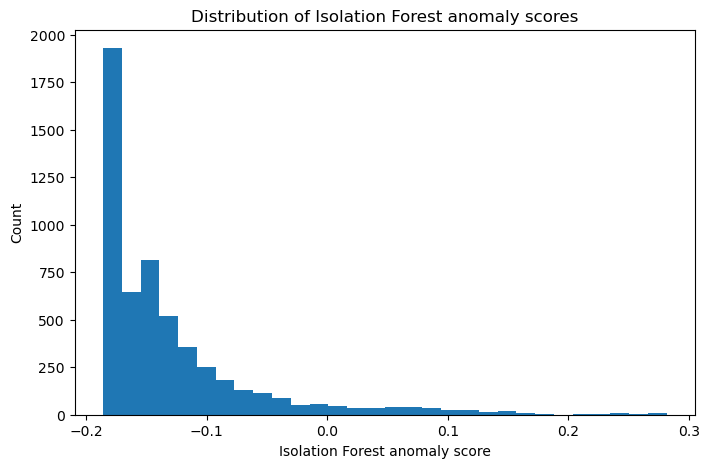

In [159]:
# Plot Isolation Forest score distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(results["if_score"], bins=30)
plt.xlabel("Isolation Forest anomaly score")
plt.ylabel("Count")
plt.title("Distribution of Isolation Forest anomaly scores")
plt.show()

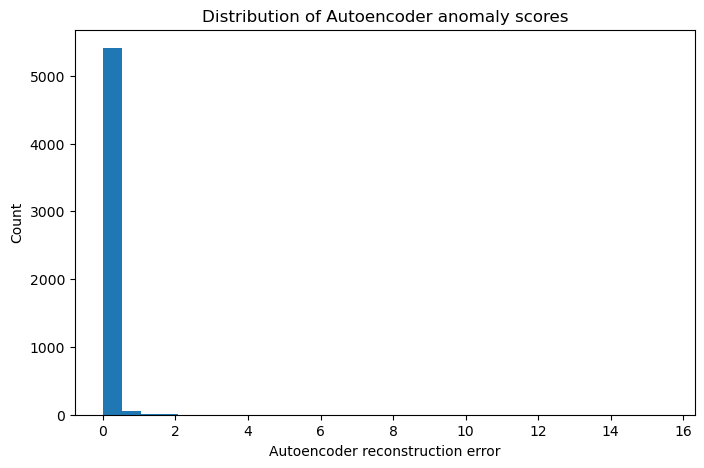

In [160]:
# Plot Autoencoder score distribution
plt.figure(figsize=(8, 5))
plt.hist(results["ae_score"], bins=30)
plt.xlabel("Autoencoder reconstruction error")
plt.ylabel("Count")
plt.title("Distribution of Autoencoder anomaly scores")
plt.show()

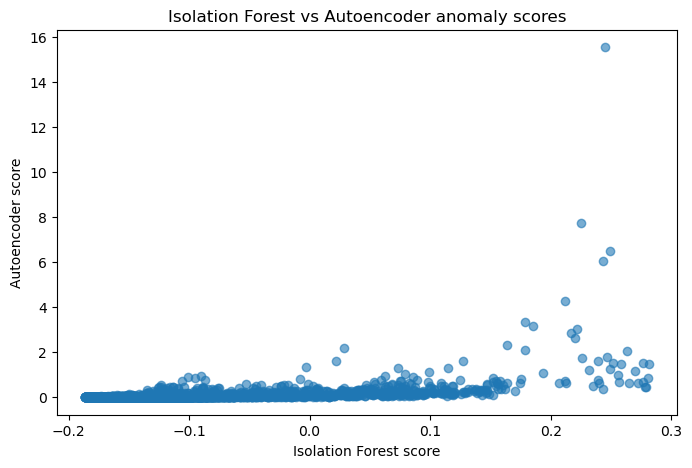

In [161]:
# Compare the two score systems
plt.figure(figsize=(8, 5))
plt.scatter(results["if_score"], results["ae_score"], alpha=0.6)
plt.xlabel("Isolation Forest score")
plt.ylabel("Autoencoder score")
plt.title("Isolation Forest vs Autoencoder anomaly scores")
plt.show()

The score distributions show that most municipality-year observations receive relatively low anomaly scores, while a smaller number of observations stand out more clearly.

The scatterplot shows that the two models sometimes agree, but also identify unusual observations in different ways.

### 7.4 Combined ranking of anomalies

In [162]:
# Rank observations in each model
results["if_rank"] = results["if_score"].rank(ascending=False, method="min")
results["ae_rank"] = results["ae_score"].rank(ascending=False, method="min")

# Average rank across the two models
results["avg_rank"] = results[["if_rank", "ae_rank"]].mean(axis=1)

# Show strongest combined anomalies
results.sort_values("avg_rank").head(10)

,municipality,year,if_score,ae_score,if_rank,ae_rank,avg_rank
3133,1480 Göteborg,2022,0.245079,15.544565,18.0,1.0,9.5
322,0180 Stockholm,2023,0.249359,6.506059,16.0,3.0,9.5
318,0180 Stockholm,2019,0.243338,6.033141,20.0,4.0,12.0
315,0180 Stockholm,2016,0.262888,2.040427,10.0,14.0,12.0
309,0180 Stockholm,2010,0.281378,1.456250,1.0,23.0,12.0
317,0180 Stockholm,2018,0.276121,1.513485,6.0,21.0,13.5
308,0180 Stockholm,2009,0.224906,7.729669,27.0,2.0,14.5
3116,1480 Göteborg,2005,0.246837,1.790699,17.0,15.0,16.0
310,0180 Stockholm,2011,0.258565,1.488863,11.0,22.0,16.5
3134,1480 Göteborg,2023,0.251465,1.530538,14.0,20.0,17.0


The combined ranking highlights municipality-year observations that receive relatively high anomaly scores in both models.

These observations provide the clearest candidates for unusual energy profiles in the dataset.

## 8. Discussion

### 8.1 Interpretation of the results

The results show that anomaly detection can identify municipality-year observations with unusual energy profiles.

The two models did not produce the same top-10 ranking, which suggests that they capture unusual patterns in different ways. Isolation Forest and the autoencoder therefore provide complementary perspectives on the data.

The combined ranking was useful because it highlighted observations that received relatively high anomaly scores in both models. These observations form the strongest candidates for unusual municipality-year energy profiles in the dataset.

### 8.2 Limitations and possible improvements

This project has several limitations.

First, the dataset does not contain labeled anomalies. This means that the results can identify unusual observations, but they cannot prove whether those observations are true anomalies in a real-world sense.

Because the dataset does not contain labeled anomalies, the results should be interpreted as ranked candidates for unusual observations rather than verified anomalies.

Second, missing values were handled with a simple imputation strategy. This made the data usable for modeling, but other imputation methods could also be explored.

Third, the model development was kept deliberately simple. Isolation Forest was used as a baseline, and the autoencoder used a limited and transparent architecture. More tuning of the autoencoder could improve the results.

If the project were continued, possible improvements would include more feature engineering, more systematic tuning of the autoencoder, and external validation using additional information about municipalities, policy changes, or known events in the energy system.

### 8.3 Practical use, architecture, and scalability

In a real setting, this type of system could be used as a screening tool.

Instead of directly making decisions, the model could help identify municipality-year observations that deserve further investigation. This could support analysts who work with energy planning, monitoring, or policy evaluation.

The current project was developed in a notebook environment on a moderate-sized dataset. In a larger real-world setting, the same pipeline could be automated and extended with scheduled data updates, model retraining, and result reporting. If the data volume became much larger, distributed storage and distributed processing could also become relevant.



## 9. Conclusion

This project examined whether anomaly detection can identify unusual municipality-year energy profiles in Swedish municipal energy data.

The results show that both Isolation Forest and the autoencoder identified observations that differ from the general pattern in the dataset. Although the models ranked observations somewhat differently, they both highlighted unusual municipality-year cases.

The investigation therefore supports the conclusion that anomaly detection can be used to identify unusual energy profiles in this type of municipal energy data.

## 10. References (En del ex)

- Statistics Sweden (SCB). Municipal energy statistics datasets used in this project:
  - Final energy use (MWh), by county and municipality, consumption category and fuel type, 2005–2008 and 2009–2023.
  - Electricity production and fuel use (MWh), by county and municipality, production type and fuel type, 2005–2008 and 2009–2023.
  - District heating production and fuel use (MWh), by county and municipality, production type and fuel type, 2005–2008 and 2009–2023.

- Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection: A survey. *ACM Computing Surveys*, 41(3), 1–58.

- Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning.

- Course lectures in Big Data Programming:
  - Deep Learning with Keras
  - Deep Learning with Keras 2 + TensorFlow
  - Anomaly Detection; AutoEncoders & GAN